In [1]:
## Load necessory Libraries
import os
import time
import copy
import random
from pathlib import Path

## ML Libraries
import numpy as np
import pandas as pd

## PyTorch libraries
import torch
from torch import nn
import torch.optim as optim
import torch.nn.functional as F
from torch.cuda.amp import autocast, GradScaler
from torch.utils.data import DataLoader, Dataset, random_split

## Torch Vission Library
import torchvision
from torchvision.models import vgg19
from torchvision.io import read_image
import torchvision.transforms as transforms

# Image processing libraries
from PIL import Image
import cv2

# Image augmentation
import albumentations as A
from albumentations.pytorch import ToTensorV2

## Visualization Libraries
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

/usr/local/lib/python3.12/dist-packages/albumentations/check_version.py:147: UserWarning: Error fetching version info <urlopen error [Errno -3] Temporary failure in name resolution>
  data = fetch_version_info()


In [2]:
## Verify versions of libraries
print("📦 Library Versions:")
print(f"   • NumPy       : {np.__version__}")
print(f"   • Pandas      : {pd.__version__}")
print(f"   • PyTorch     : {torch.__version__}")
print(f"   • Torchvision : {torchvision.__version__}")
print(f"   • Matplotlib  : {plt.matplotlib.__version__}")
print(f"   • Seaborn     : {sns.__version__}")

print("—" * 60)

## Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
n_gpu = torch.cuda.device_count()
print(f"🚀 Using device: {device}")
print(f"   Number of GPU devices: {n_gpu}")

for i in range(n_gpu):
    props = torch.cuda.get_device_properties(i)
    total_mem_gb = props.total_memory / (1024 ** 3)
    print(f"\n   GPU {i}: {props.name}")
    print(f"        • Compute Capability : {props.major}.{props.minor}")
    print(f"        • Total Memory       : {total_mem_gb:.2f} GB")
    print(f"        • Multi Processors   : {props.multi_processor_count}")
    print(f"        • CUDA Cores (est.)  : depends on architecture")
    print("—" * 60)

📦 Library Versions:
   • NumPy       : 2.0.2
   • Pandas      : 2.3.3
   • PyTorch     : 2.10.0+cu128
   • Torchvision : 0.25.0+cu128
   • Matplotlib  : 3.10.0
   • Seaborn     : 0.13.2
————————————————————————————————————————————————————————————
🚀 Using device: cuda
   Number of GPU devices: 2

   GPU 0: Tesla T4
        • Compute Capability : 7.5
        • Total Memory       : 14.56 GB
        • Multi Processors   : 40
        • CUDA Cores (est.)  : depends on architecture
————————————————————————————————————————————————————————————

   GPU 1: Tesla T4
        • Compute Capability : 7.5
        • Total Memory       : 14.56 GB
        • Multi Processors   : 40
        • CUDA Cores (est.)  : depends on architecture
————————————————————————————————————————————————————————————


In [3]:
## Environment setup and variable initialization
ROOT = Path.cwd() / "/kaggle/input/competitions/plant-leaves-super-resolution-challenge"
OUT_DIR = Path.cwd() / "/kaggle/working"

TRAIN_HR_DIR = ROOT / "train_High_Resolution"
TRAIN_LR_DIR = ROOT / "train_Low_Resolution"
TEST_LR_DIR = ROOT / "test_Low_Resolution"
VGG_PATH = ROOT / "vgg19_weights.pth"

SUBMISSION_CSV = ROOT / "submission.csv"
SAMPLE_SUBMISSION_CSV = ROOT / "sample_submission.csv"

print(f"📁 Data Paths:")
print(f"   • Root Directory         : '{ROOT}'")
print(f"   • Output Directory       : '{OUT_DIR}'")
print(f"   • Training High Res Dir. : '{TRAIN_HR_DIR}'")
print(f"   • Training Low Res Dir.  : '{TRAIN_LR_DIR}'")
print(f"   • Test Low Res Dir.      : '{TEST_LR_DIR}'")
print(f"   • Submission CSV         : '{SUBMISSION_CSV}'")
print(f"   • Sample Submission CSV  : '{SAMPLE_SUBMISSION_CSV}'")
print()
print(f"💾 No. of Samples:")
print(f"   • Training High Res Dir. : {len(os.listdir(TRAIN_HR_DIR))}")
print(f"   • Training Low Res Dir.  : {len(os.listdir(TRAIN_LR_DIR))}")
print(f"   • Test Low Res Dir.      : {len(os.listdir(TEST_LR_DIR))}")

# Set random seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
# torch.backends.cudnn.benchmark = True
print(f"\n🌱 Random seeds set to {SEED} for reproducible experiments")

📁 Data Paths:
   • Root Directory         : '/kaggle/input/competitions/plant-leaves-super-resolution-challenge'
   • Output Directory       : '/kaggle/working'
   • Training High Res Dir. : '/kaggle/input/competitions/plant-leaves-super-resolution-challenge/train_High_Resolution'
   • Training Low Res Dir.  : '/kaggle/input/competitions/plant-leaves-super-resolution-challenge/train_Low_Resolution'
   • Test Low Res Dir.      : '/kaggle/input/competitions/plant-leaves-super-resolution-challenge/test_Low_Resolution'
   • Submission CSV         : '/kaggle/input/competitions/plant-leaves-super-resolution-challenge/submission.csv'
   • Sample Submission CSV  : '/kaggle/input/competitions/plant-leaves-super-resolution-challenge/sample_submission.csv'

💾 No. of Samples:
   • Training High Res Dir. : 1642
   • Training Low Res Dir.  : 1642
   • Test Low Res Dir.      : 495

🌱 Random seeds set to 42 for reproducible experiments


---

## Data Preperations

In [4]:
## =========================================
## List LR/HR Paires from the train dataset.
## =========================================
def list_pairs(hr_dir, lr_dir):
    hr_files = sorted(os.listdir(hr_dir))
    pairs = []
    for f in hr_files:
        lr_path = os.path.join(lr_dir, f)
        hr_path = os.path.join(hr_dir, f)
        if os.path.exists(lr_path) and os.path.exists(hr_path):
            pairs.append((lr_path, hr_path, f))
    return pairs

## ==========================================
## PIL RGB (HWC) -> float tensor [0,1] (CHW).
## ==========================================
def pil_to_tensor01(img):
    arr = np.asarray(img.convert("RGB"), dtype=np.float32) / 255.0
    return torch.from_numpy(arr).permute(2, 0, 1).contiguous()

In [5]:
## ====================================
## The Dataset class for train dataset.
## Only used for LR/HR Paires.
## ====================================
class SRDataset(Dataset):
    def __init__(self, pairs, augment=True):
        self.pairs = pairs
        self.augment = augment

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        lr_path, hr_path, fname = self.pairs[idx]
        lr_t = read_image(lr_path).float() / 255.0
        hr_t = read_image(hr_path).float() / 255.0

        if self.augment:
            if random.random() < 0.5:
                lr_t = torch.flip(lr_t, [-1])
                hr_t = torch.flip(hr_t, [-1])
            if random.random() < 0.5:
                lr_t = torch.flip(lr_t, [-2])
                hr_t = torch.flip(hr_t, [-2])
            k = random.randint(0, 3)
            if k:
                lr_t = torch.rot90(lr_t, k, [-2, -1])
                hr_t = torch.rot90(hr_t, k, [-2, -1])

        return lr_t, hr_t, fname

## ====================================================
## The Dataset class for test dataset.
## Only for LR images. Need to pass the directory only.
## ====================================================
class SR_TestDataset(Dataset):
    def __init__(self, test_dir):
        self.files = sorted(os.listdir(test_dir))
        self.test_dir = test_dir

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        f = self.files[idx]
        # lr = Image.open(os.path.join(self.test_dir, f)).convert("RGB")
        lr = read_image(os.path.join(self.test_dir, f)).float() / 255.0
        return lr, f

## =============================================
## Function to create Dataloaders from Datasets.
## Used for both Train and Test Dataset.
## =============================================
def create_dataloader(dataset, train=True, batch_size=32, num_workers=0):
    return DataLoader(
        dataset,
        batch_size=batch_size if train else 1,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=train
    )

In [6]:
## ================================
## Prepare the train and validation
## data loaders.
## ================================
FINAL_RUN = True
VAL_FRAC = 0.05

print(f"👀 Collecting training set...")
ALL_PAIRS = list_pairs(TRAIN_HR_DIR, TRAIN_LR_DIR)
random.Random(SEED).shuffle(ALL_PAIRS)
print(f"   • Found {len(ALL_PAIRS)} training pairs")

## Split Train and Validation Dataset
if FINAL_RUN:
    TRAIN_PAIRS = ALL_PAIRS
    VAL_PAIRS = ALL_PAIRS[:32] # Tiny set for loss monitoring
    print(f"\n🛻 FINAL RUN:")
    print(f"   • Train: {len(TRAIN_PAIRS)} (all data)")
    print(f"   • Peek : {len(VAL_PAIRS)}")
else:
    n_val = max(1, int(len(ALL_PAIRS) * VAL_FRAC))
    VAL_PAIRS = ALL_PAIRS[:n_val]
    TRAIN_PAIRS = ALL_PAIRS[n_val:]
    print(f"\n🪓 Split:")
    print(f"   • Train: {len(TRAIN_PAIRS)}")
    print(f"   • Val  : {len(VAL_PAIRS)}")

train_dataset = SRDataset(TRAIN_PAIRS, augment=True)
val_dataset = SRDataset(VAL_PAIRS, augment=False)

train_loader = create_dataloader(train_dataset, train=True)
val_loader = create_dataloader(val_dataset, train=False)

## Sanity Checks
lr, hr, f = next(iter(train_loader))
print("\n✅ Sanity Check (B, C, H, W):")
print("   • LR shape:", lr.shape)   # (B, 3, 32, 32)
print("   • HR shape:", hr.shape)   # (B, 3, 128, 128)

👀 Collecting training set...
   • Found 1642 training pairs

🛻 FINAL RUN:
   • Train: 1642 (all data)
   • Peek : 32

✅ Sanity Check (B, C, H, W):
   • LR shape: torch.Size([32, 3, 32, 32])
   • HR shape: torch.Size([32, 3, 128, 128])


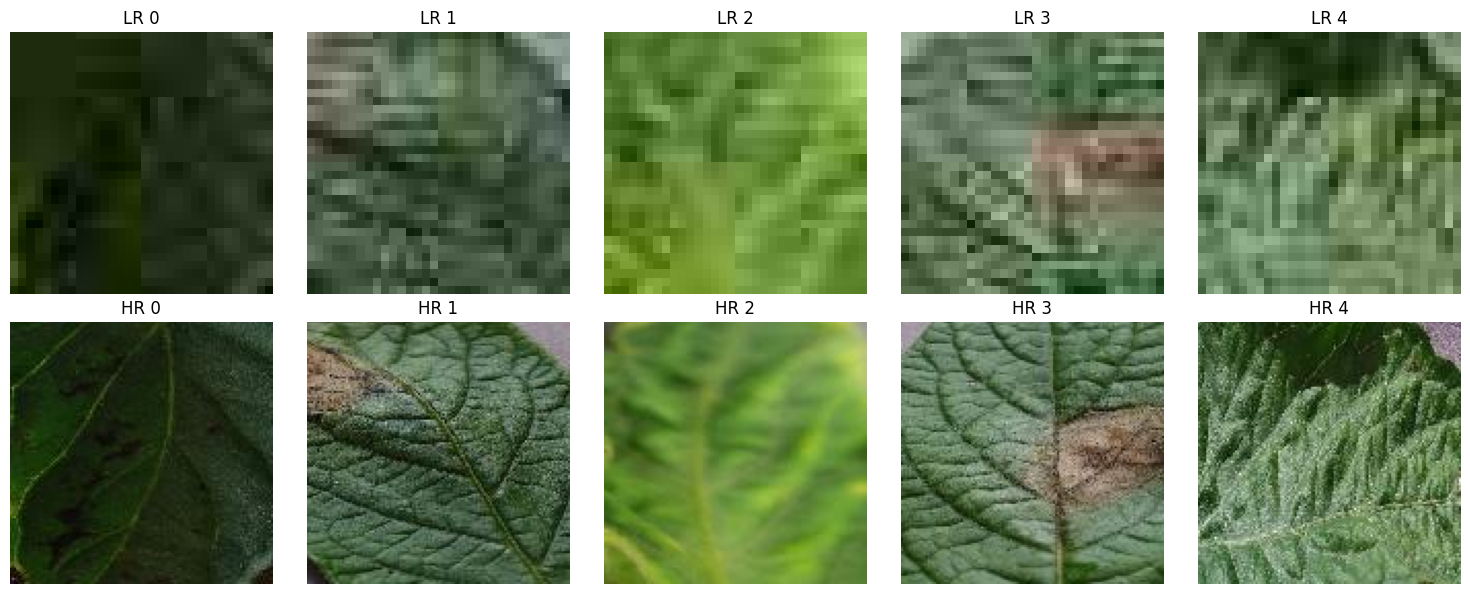

In [7]:
## Draw random samples
indices = random.sample(range(len(train_dataset)), 5)
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i, idx in enumerate(indices):
    lr, hr, f = train_dataset[idx]
    
    # Convert from (C,H,W) → (H,W,C)
    lr_img = lr.permute(1, 2, 0).numpy()
    hr_img = hr.permute(1, 2, 0).numpy()
    
    # Plot LR (top row)
    axes[0, i].imshow(lr_img)
    axes[0, i].set_title(f"LR {i}")
    axes[0, i].axis("off")
    
    # Plot HR (bottom row)
    axes[1, i].imshow(hr_img)
    axes[1, i].set_title(f"HR {i}")
    axes[1, i].axis("off")
plt.tight_layout()
plt.show()

---

## Some Utility functions for Training

In [8]:
## ===============================
## Use multiple available GPUs
## Move the model to the GPUs
## ===============================
def useGPU(model):
    if torch.cuda.device_count() > 1:
        model = nn.DataParallel(model)
    return model.to(device)

## Model Setup

In [9]:
## ==================================================
## 1. Initialize network with Kaiming-normal weights
## 2. Scale down conv weights to stabilize training
## ==================================================
def default_init(m):
    if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d)):
        nn.init.kaiming_normal_(m.weight, a=0.2, mode='fan_in', nonlinearity='leaky_relu')
        m.weight.data *= 0.1
        if m.bias is not None:
            nn.init.zeros_(m.bias)
    elif isinstance(m, nn.Linear):
        nn.init.kaiming_normal_(m.weight)
        if m.bias is not None:
            nn.init.zeros_(m.bias)

In [10]:
class DenseBlock(nn.Module):
    def __init__(self, nf=64, gc=32):
        super().__init__()
        self.conv1 = nn.Conv2d(nf + 0 * gc, gc, 3, 1, 1)
        self.conv2 = nn.Conv2d(nf + 1 * gc, gc, 3, 1, 1)
        self.conv3 = nn.Conv2d(nf + 2 * gc, gc, 3, 1, 1)
        self.conv4 = nn.Conv2d(nf + 3 * gc, gc, 3, 1, 1)
        self.conv5 = nn.Conv2d(nf + 4 * gc, nf, 3, 1, 1)
        self.lrelu = nn.LeakyReLU(0.2, inplace=True)

    def forward(self, x):
        x1 = self.lrelu(self.conv1(x))
        x2 = self.lrelu(self.conv2(torch.cat([x, x1], 1)))
        x3 = self.lrelu(self.conv3(torch.cat([x, x1, x2], 1)))
        x4 = self.lrelu(self.conv4(torch.cat([x, x1, x2, x3], 1)))
        x5 = self.conv5(torch.cat([x, x1, x2, x3, x4], 1))
        return x5 * 0.2 + x

class RRDB(nn.Module):
    def __init__(self, nf=64, gc=32):
        super().__init__()
        self.db1 = DenseBlock(nf, gc)
        self.db2 = DenseBlock(nf, gc)
        self.db3 = DenseBlock(nf, gc)

    def forward(self, x):
        out = self.db1(x)
        out = self.db2(out)
        out = self.db3(out)
        return out * 0.2 + x

In [11]:
## =========================================================
## RRDB generator predicting residual over bicubic upsample.
## Input:  (B, 3,  32,  32) in [0,1]
## Output: (B, 3, 128, 128) in [0,1]
## =========================================================
class RRDBNet(nn.Module):
    def __init__(self, nf=64, n_blocks=16, gc=32, scale=4):
        super().__init__()
        self.scale = scale
        self.conv_in = nn.Conv2d(3, nf, 3, 1, 1)
        self.body = nn.Sequential(*[RRDB(nf, gc) for _ in range(n_blocks)])
        self.conv_trunk = nn.Conv2d(nf, nf, 3, 1, 1)

        # Upsample x2 then x2 using pixel-shuffle
        self.up1 = nn.Conv2d(nf, nf * 4, 3, 1, 1)
        self.up2 = nn.Conv2d(nf, nf * 4, 3, 1, 1)
        self.pshuf = nn.PixelShuffle(2)

        self.conv_hr = nn.Conv2d(nf, nf, 3, 1, 1)
        self.conv_out = nn.Conv2d(nf, 3, 3, 1, 1)
        self.lrelu = nn.LeakyReLU(0.2, inplace=True)

        self.apply(default_init)

    def forward(self, x):
        base = F.interpolate(x, scale_factor=self.scale, mode='bicubic', align_corners=False)

        feat = self.conv_in(x)
        trunk = self.conv_trunk(self.body(feat))
        feat = feat + trunk

        feat = self.lrelu(self.pshuf(self.up1(feat)))
        feat = self.lrelu(self.pshuf(self.up2(feat)))
        feat = self.lrelu(self.conv_hr(feat))
        residual = self.conv_out(feat)

        return base + residual

In [12]:
## ============================================================
## PatchGAN Discriminator (Conditional on bicubic-upsampled LR)
## Inputs:
##     - cond: bicubic-upsampled LR (B,3,128,128)
##     -  img: HR or SR             (B,3,128,128)
## ============================================================
class Discriminator(nn.Module):
    def __init__(self, in_ch=6, base=64):
        super().__init__()
        
        def block(ic, oc, stride=2, bn=True):
            layers = [nn.Conv2d(ic, oc, 4, stride, 1)]
            if bn:
                layers.append(nn.BatchNorm2d(oc))
            layers.append(nn.LeakyReLU(0.2, inplace=True))
            return nn.Sequential(*layers)

        self.net = nn.Sequential(
            block(in_ch, base, 2, bn=False),  # 128 -> 64
            block(base, base*2, 2),           # 64 -> 32
            block(base*2, base*4, 2),         # 32 -> 16
            block(base*4, base*8, 2),         # 16 -> 8
            block(base*8, base*8, 1),         # 8 -> 8
            nn.Conv2d(base*8, 1, 4, 1, 1),    # 8 -> 7 patch logits
        )
        self.apply(default_init)

    def forward(self, cond, img):
        x = torch.cat([cond, img], dim=1)
        return self.net(x)

In [13]:
## ==============================================
## Features from VGG-19. Weights loaded locally.
## Inputs:
##     - sr: Super Resolution (B,3,128,128)
##     - hr: High Resolution  (B,3,128,128)
## ==============================================
class VGGPerceptual(nn.Module):
    def __init__(self, weights_path, feature_layer=35):
        super().__init__()
        vgg = vgg19(weights=None)
        
        # Load provided weights from file
        state = torch.load(weights_path, map_location="cpu")
        try:
            vgg.load_state_dict(state)
        except Exception:
            vgg.load_state_dict(state, strict=False)
        
        feats = vgg.features[:feature_layer + 1].eval()
        for p in feats.parameters():
            p.requires_grad = False
        self.feats = feats

        # ImageNet normalization constants
        self.register_buffer("mean", torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1))
        self.register_buffer("std",  torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1))

    def forward(self, sr, hr):
        sr_n = (sr - self.mean) / self.std
        hr_n = (hr - self.mean) / self.std
        return F.l1_loss(self.feats(sr_n), self.feats(hr_n))

In [14]:
def charbonnier(pred, target, eps=1e-3):
    return torch.mean(torch.sqrt((pred - target)**2 + eps**2))

---

## Model Training

In [15]:
## ===============
## Configurations
## ===============
CFG = {
    "scale": 4,
    "warmup_epochs": 100,     # pure L1 + perceptual (no GAN)
    "gan_epochs": 10,        # add tiny GAN signal for texture sharpness
    "lr_g": 2e-4,
    "lr_d": 1e-4,
    "beta1": 0.9,
    "beta2": 0.999,
    
    # Loss weights - heavily tilted toward L1 because leaderboard is MAE
    "lambda_l1":   100.0,
    "lambda_perc": 1.0,
    "lambda_adv":  0.001,    # very small - GAN only nudges texture

    "use_perceptual": False,
    "grad_clip": 1.0,
}

In [16]:
## =========================================================
## Define Generator, Discriminator & Perceptual Loss Models
## =========================================================
G = useGPU(RRDBNet(nf=64, n_blocks=22, gc=32, scale=4))
n_params_g = sum(p.numel() for p in G.parameters())
print(f"Generator params    : {n_params_g/1e6:.2f} M")

D = useGPU(Discriminator(in_ch=6, base=64))
n_params_d = sum(p.numel() for p in D.parameters())
print(f"Discriminator params: {n_params_d/1e6:.2f} M")

vgg_loss = None
if CFG["use_perceptual"] and os.path.exists(VGG_PATH):
    try:
        vgg_loss = VGGPerceptual(VGG_PATH).to(device)
        vgg_loss.eval()
        print("\nVGG perceptual loss loaded from", VGG_PATH)
    except Exception as e:
        print("\nPerceptual loss disabled:", e)
        vgg_loss = None
else:
    print("\nPerceptual loss disabled (no weights file or turned off).")

Generator params    : 16.20 M
Discriminator params: 6.97 M

Perceptual loss disabled (no weights file or turned off).


In [17]:
## ==========================================
## Optimizers, schedulers, validation MAE
## ==========================================
opt_G = optim.Adam(G.parameters(), lr=CFG["lr_g"], betas=(CFG["beta1"], CFG["beta2"]))
opt_D = optim.Adam(D.parameters(), lr=CFG["lr_d"], betas=(CFG["beta1"], CFG["beta2"]))

total_epochs = CFG["warmup_epochs"] + CFG["gan_epochs"]
sched_G = optim.lr_scheduler.CosineAnnealingLR(opt_G, T_max=total_epochs, eta_min=1e-6)
sched_D = optim.lr_scheduler.CosineAnnealingLR(opt_D, T_max=total_epochs, eta_min=1e-6)
# sched_G = optim.lr_scheduler.CosineAnnealingWarmRestarts(opt_G, T_max=total_epochs, eta_min=1e-6)
# sched_D = optim.lr_scheduler.CosineAnnealingWarmRestarts(opt_D, T_max=total_epochs, eta_min=1e-6)
# CosineAnnealingWarmRestarts(T_0=20, T_mult=2)

scaler_G = GradScaler()
scaler_D = GradScaler()

bce = nn.BCEWithLogitsLoss()
l1  = nn.L1Loss()


## ===================================================
## Utility Function to Validate over dataset
## MAE on [0,255] scale - mirrors leaderboard metric
## ===================================================
@torch.no_grad()
def validate(model, loader):
    model.eval()
    total_mae, n = 0.0, 0
    for lr, hr, _ in loader:
        lr = lr.to(device, non_blocking=True)
        hr = hr.to(device, non_blocking=True)
        with autocast():
            sr = model(lr).clamp(0.0, 1.0)
        
        mae = (sr * 255.0 - hr * 255.0).abs().mean().item()
        bs = lr.size(0)
        total_mae += mae * bs
        n += bs
    model.train()
    return total_mae / n

In [18]:
# ============================================================
# Warmup - Generator-only training with L1 (+ perceptual)
# This builds the MAE-accurate base. No discriminator.
# ============================================================
best_val_mae = float("inf")
best_path = os.path.join(OUT_DIR, "G_best.pth")
warmup_path = os.path.join(OUT_DIR, "G_warmup_last.pth")
G.train()

for epoch in range(1, CFG["warmup_epochs"] + 1):
    t0 = time.time()
    running = {"l1": 0.0, "perc": 0.0}
    count = 0

    loop = tqdm(train_loader, desc=f"Epoch [{epoch:03d}/{CFG["warmup_epochs"]}]")
    for lr, hr, _ in loop:
        lr = lr.to(device, non_blocking=True)
        hr = hr.to(device, non_blocking=True)

        opt_G.zero_grad(set_to_none=True)
        with autocast():
            sr = G(lr)
            sr_cl = sr.clamp(0.0, 1.0) # For perceptual loss

            # loss_l1 = l1(sr, hr)
            loss_l1 = charbonnier(sr, hr) + 0.1 * F.mse_loss(sr, hr)
            loss_p  = vgg_loss(sr_cl, hr) if vgg_loss is not None else torch.tensor(0.0, device=device)

            loss = CFG["lambda_l1"] * loss_l1 + CFG["lambda_perc"] * loss_p

        scaler_G.scale(loss).backward()
        scaler_G.unscale_(opt_G)
        torch.nn.utils.clip_grad_norm_(G.parameters(), CFG["grad_clip"])
        scaler_G.step(opt_G)
        scaler_G.update()

        running["l1"]   += loss_l1.item() * lr.size(0)
        running["perc"] += float(loss_p)  * lr.size(0)
        count += lr.size(0)

    sched_G.step()

    val_mae = validate(G, val_loader)
    if val_mae < best_val_mae:
        best_val_mae = val_mae
        torch.save(G.state_dict(), best_path)

    print(f"[Warmup {epoch:03d}/{CFG['warmup_epochs']}] "
          f"L1={running['l1']/count:.4f} | Perc={running['perc']/count:.4f} | "
          f"Val MAE(0-255)={val_mae:.3f} | Best={best_val_mae:.3f} | "
          f"lr={opt_G.param_groups[0]['lr']:.2e} | {time.time()-t0:.1f}s")

torch.save(G.state_dict(), warmup_path)
print("Warmup complete.")
print("   • Best val MAE:", best_val_mae)
print("   • Best Saved  :", best_path)
print("   • Final Saved :", warmup_path)

Epoch [001/100]:   0%|          | 0/52 [00:00<?, ?it/s]

[Warmup 001/100] L1=0.0725 | Perc=0.0000 | Val MAE(0-255)=18.816 | Best=18.816 | lr=2.00e-04 | 39.5s


Epoch [002/100]:   0%|          | 0/52 [00:00<?, ?it/s]

[Warmup 002/100] L1=0.0711 | Perc=0.0000 | Val MAE(0-255)=18.678 | Best=18.678 | lr=2.00e-04 | 26.6s


Epoch [003/100]:   0%|          | 0/52 [00:00<?, ?it/s]

...

[Warmup 098/100] L1=0.0673 | Perc=0.0000 | Val MAE(0-255)=17.791 | Best=17.789 | lr=6.79e-06 | 29.4s


Epoch [099/100]:   0%|          | 0/52 [00:00<?, ?it/s]

[Warmup 099/100] L1=0.0673 | Perc=0.0000 | Val MAE(0-255)=17.788 | Best=17.788 | lr=5.87e-06 | 23.8s


Epoch [100/100]:   0%|          | 0/52 [00:00<?, ?it/s]

[Warmup 100/100] L1=0.0673 | Perc=0.0000 | Val MAE(0-255)=17.788 | Best=17.788 | lr=5.03e-06 | 24.4s
Warmup complete.
   • Best val MAE: 17.78772273659706
   • Best Saved  : /kaggle/working/G_best.pth
   • Final Saved : /kaggle/working/G_warmup_last.pth


In [19]:
# ============================================================
# GAN fine-tune - adds very small adversarial signal
# If val MAE worsens, we keep the warmup-best checkpoint.
# ============================================================
final_path = os.path.join(OUT_DIR, "G_final.pth")
if FINAL_RUN:
    G.load_state_dict(torch.load(warmup_path, map_location=device))
else:
    G.load_state_dict(torch.load(best_path, map_location=device))
G.train()
D.train()

for epoch in range(1, CFG["gan_epochs"] + 1):
    t0 = time.time()
    running = {"l1": 0.0, "perc": 0.0, "adv": 0.0, "d": 0.0}
    count = 0

    loop = tqdm(train_loader, desc=f"Epoch [{epoch:03d}/{CFG["gan_epochs"]}]")
    for lr, hr, _ in loop:
        lr = lr.to(device, non_blocking=True)
        hr = hr.to(device, non_blocking=True)
        cond = F.interpolate(lr, scale_factor=4, mode='bicubic', align_corners=False).clamp(0, 1)

        # ===== Train D =====
        opt_D.zero_grad(set_to_none=True)
        with autocast():
            with torch.no_grad():
                sr = G(lr).clamp(0, 1)
            d_real = D(cond, hr)
            d_fake = D(cond, sr.detach())
            
            loss_d = 0.5 * (
                bce(d_real - d_fake.mean(), torch.ones_like(d_real)) +
                bce(d_fake - d_real.mean(), torch.zeros_like(d_fake))
            )
        scaler_D.scale(loss_d).backward()
        scaler_D.unscale_(opt_D)
        torch.nn.utils.clip_grad_norm_(D.parameters(), CFG["grad_clip"])
        scaler_D.step(opt_D)
        scaler_D.update()

        # ===== Train G =====
        opt_G.zero_grad(set_to_none=True)
        with autocast():
            sr = G(lr)
            sr_cl = sr.clamp(0, 1)
            d_real = D(cond, hr).detach()
            d_fake = D(cond, sr_cl)
            
            loss_adv = 0.5 * (
                bce(d_real - d_fake.mean(), torch.zeros_like(d_real)) +
                bce(d_fake - d_real.mean(), torch.ones_like(d_fake))
            )
            # loss_l1 = l1(sr, hr)
            loss_l1 = charbonnier(sr, hr) + 0.1 * F.mse_loss(sr, hr)
            loss_p  = vgg_loss(sr_cl, hr) if vgg_loss is not None else torch.tensor(0.0, device=device)
            loss_g = (CFG["lambda_l1"]   * loss_l1 +
                      CFG["lambda_perc"] * loss_p  +
                      CFG["lambda_adv"]  * loss_adv)

        scaler_G.scale(loss_g).backward()
        scaler_G.unscale_(opt_G)
        torch.nn.utils.clip_grad_norm_(G.parameters(), CFG["grad_clip"])
        scaler_G.step(opt_G)
        scaler_G.update()

        running["l1"]   += loss_l1.item()  * lr.size(0)
        running["perc"] += float(loss_p)   * lr.size(0)
        running["adv"]  += loss_adv.item() * lr.size(0)
        running["d"]    += loss_d.item()   * lr.size(0)
        count += lr.size(0)

    sched_G.step()
    sched_D.step()

    val_mae = validate(G, val_loader)
    if val_mae < best_val_mae:
        best_val_mae = val_mae
        torch.save(G.state_dict(), best_path)
        tag = " *BEST*"
    else:
        tag = ""

    print(f"[GAN {epoch:03d}/{CFG['gan_epochs']}] "
          f"L1={running['l1']/count:.4f} Perc={running['perc']/count:.4f} "
          f"Adv={running['adv']/count:.4f} D={running['d']/count:.4f} | "
          f"Val MAE={val_mae:.3f} | Best={best_val_mae:.3f}{tag} | "
          f"{time.time()-t0:.1f}s")

torch.save(G.state_dict(), final_path)
print("Final training complete.")
print("   • Best val MAE:", best_val_mae)
print("   • Saved:", final_path)

Epoch [001/10]:   0%|          | 0/52 [00:00<?, ?it/s]

[GAN 001/10] L1=0.0673 Perc=0.0000 Adv=4.3404 D=0.1635 | Val MAE=17.786 | Best=17.786 *BEST* | 37.3s


Epoch [002/10]:   0%|          | 0/52 [00:00<?, ?it/s]

[GAN 002/10] L1=0.0673 Perc=0.0000 Adv=8.8450 D=0.0004 | Val MAE=17.788 | Best=17.786 | 37.1s


Epoch [003/10]:   0%|          | 0/52 [00:00<?, ?it/s]

...

[GAN 008/10] L1=0.0673 Perc=0.0000 Adv=10.9583 D=0.0000 | Val MAE=17.785 | Best=17.785 *BEST* | 38.1s


Epoch [009/10]:   0%|          | 0/52 [00:00<?, ?it/s]

[GAN 009/10] L1=0.0673 Perc=0.0000 Adv=11.1374 D=0.0000 | Val MAE=17.786 | Best=17.785 | 38.1s


Epoch [010/10]:   0%|          | 0/52 [00:00<?, ?it/s]

[GAN 010/10] L1=0.0673 Perc=0.0000 Adv=11.3010 D=0.0000 | Val MAE=17.785 | Best=17.785 *BEST* | 37.7s
Final training complete.
   • Best val MAE: 17.785238593816757
   • Saved: /kaggle/working/G_final.pth


---

## Inference with Self-Ensemble & Submission

In [20]:
## ============================================================
## Self-ensemble:
## predict on 8 transforms, inverse-transform, average.
## ============================================================
def augment(x, k=0, hflip=False, vflip=False):
    if hflip:
        x = torch.flip(x, dims=[-1])
    if vflip:
        x = torch.flip(x, dims=[-2])
    if k:
        x = torch.rot90(x, k, dims=[-2, -1])
    return x

def deaugment(x, k=0, hflip=False, vflip=False):
    if k:
        x = torch.rot90(x, -k, dims=[-2, -1])
    if vflip:
        x = torch.flip(x, dims=[-2])
    if hflip:
        x = torch.flip(x, dims=[-1])
    return x

@torch.no_grad()
def predict_self_ensemble(model, lr_batch):
    outputs = []

    for hflip in [False, True]:
        for vflip in [False, True]:
            for k in range(4):
                inp = augment(lr_batch, k=k, hflip=hflip, vflip=vflip)
                # with autocast():
                #     pred = model(inp).clamp(0.0, 1.0)
                pred = model(inp.float()).clamp(0.0, 1.0).float()
                pred = deaugment(pred, k=k, hflip=hflip, vflip=vflip)
    
                outputs.append(pred.float())

    return torch.mean(torch.stack(outputs, dim=0), dim=0)

In [21]:
test_dataset = SR_TestDataset(TEST_LR_DIR)
test_loader = create_dataloader(test_dataset, False)

In [22]:
## ============================================================
## Inference with 8-way self-ensemble + CSV submission
## Averaging MAE-trained outputs reduces MAE further.
## ============================================================
if FINAL_RUN:
    G.load_state_dict(torch.load(final_path, map_location=device))
else:
    G.load_state_dict(torch.load(best_path, map_location=device))
G.eval()

rows = []
for lr, fnames in tqdm(test_loader, desc="Inference"):
    lr = lr.to(device, non_blocking=True)
    sr = predict_self_ensemble(G, lr)                # (B,3,128,128) in [0,1]
    sr_np = (sr.clamp(0, 1).cpu().numpy() * 255.0).round().astype(np.uint8)
    
    # Shape: (B, 3, 128, 128) -> transpose to (B, 128, 128, 3)
    sr_np = np.transpose(sr_np, (0, 2, 3, 1)) # BHWC
    
    for i, fname in enumerate(fnames):
        flat = sr_np[i].reshape(-1)               # 128*128*3 = 49152, row-major RGB
        pixels_str = " ".join(flat.astype(np.int32).astype(str))
        rows.append((fname, pixels_str))

sub = pd.DataFrame(rows, columns=["Id", "Pixels"])
sub_path = os.path.join(OUT_DIR, "submission.csv")
sub.to_csv(sub_path, index=False)

# Sanity checks
print(f"Rows: {len(sub)} (expected {len(test_dataset)})")
sample_vals = list(map(int, sub.iloc[0]["Pixels"].split()))
print(f"First row pixel count: {len(sample_vals)} (expected 49152)")
print(f"Pixel range: [{min(sample_vals)}, {max(sample_vals)}]")
print("Saved:", sub_path)
sub.head(2)

Inference:   0%|          | 0/495 [00:00<?, ?it/s]

Rows: 495 (expected 495)
First row pixel count: 49152 (expected 49152)
Pixel range: [36, 126]
Saved: /kaggle/working/submission.csv


,Id,Pixels
0,agrivision_test_0133.png,76 103 78 75 102 76 75 102 76 74 101 74 72 99 ...
1,agrivision_test_0428.png,94 121 89 96 122 90 99 125 92 104 129 97 108 1...


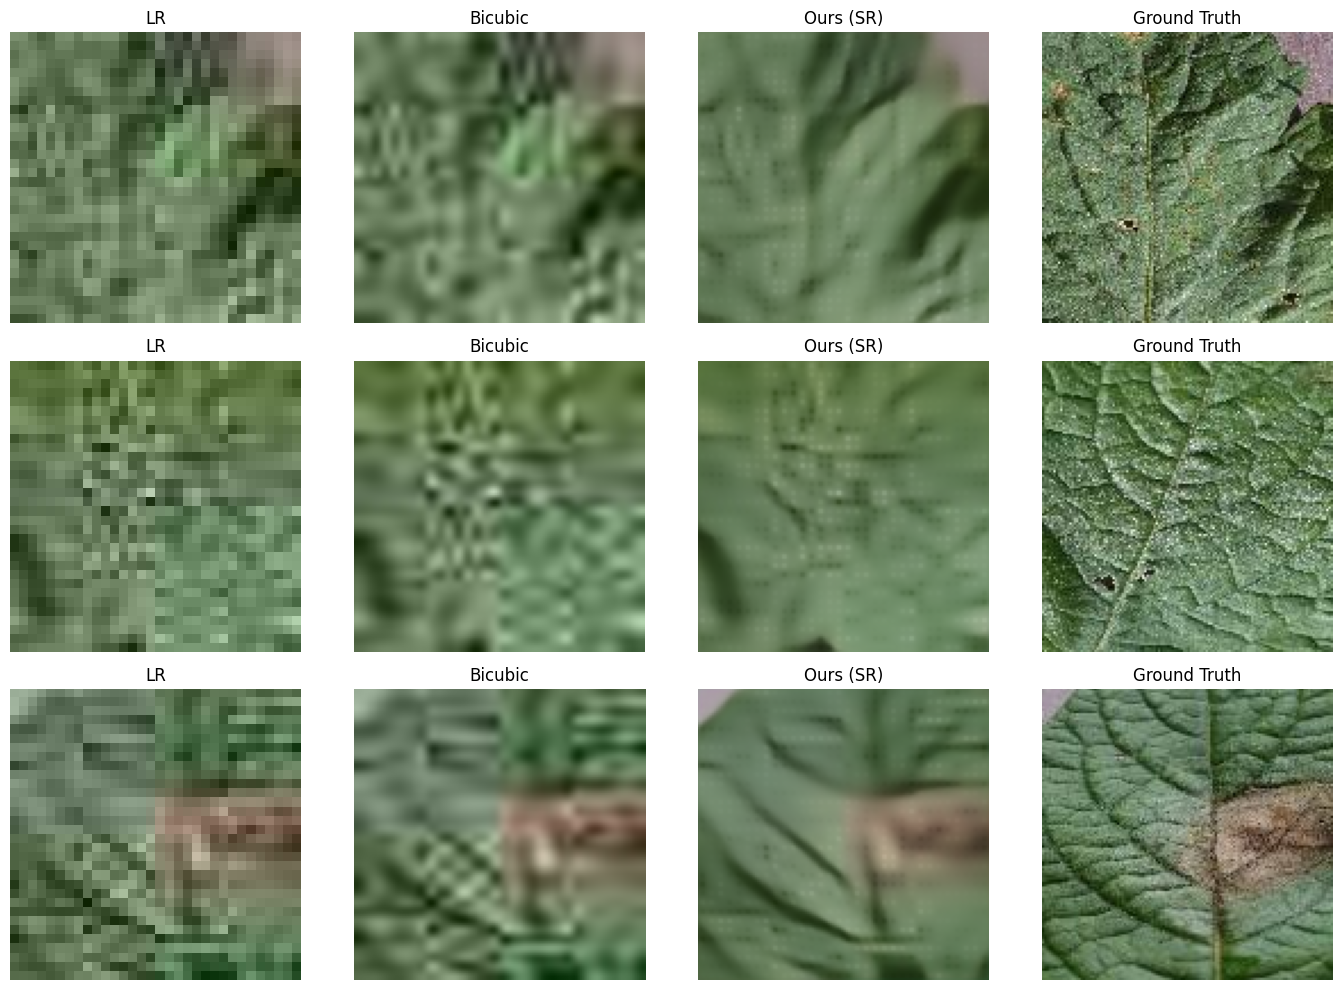

In [23]:
## =================================================
## Visual sanity check on a few validation samples
## =================================================
G.eval()
fig, axes = plt.subplots(3, 4, figsize=(14, 10))

with torch.no_grad():
    for row, (lr, hr, fn) in enumerate(val_loader):
        if row >= 3: break
        lr_s = lr[:1].to(device)
        hr_s = hr[:1]
        sr = predict_self_ensemble(G, lr_s).clamp(0, 1).cpu()
        bic = F.interpolate(lr_s, scale_factor=4, mode='bicubic', align_corners=False).clamp(0,1).cpu()

        axes[row, 0].imshow(lr[:1][0].permute(1,2,0).numpy()); axes[row,0].set_title("LR");           axes[row,0].axis("off")
        axes[row, 1].imshow(bic[0].permute(1,2,0).numpy());    axes[row,1].set_title("Bicubic");      axes[row,1].axis("off")
        axes[row, 2].imshow(sr[0].permute(1,2,0).numpy());     axes[row,2].set_title("Ours (SR)");    axes[row,2].axis("off")
        axes[row, 3].imshow(hr_s[0].permute(1,2,0).numpy());   axes[row,3].set_title("Ground Truth"); axes[row,3].axis("off")
        
plt.tight_layout()
plt.show()